In [4]:
#data structures
import pandas as pd
import numpy as np

#machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler

#metrics (performace and machine learning scores)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import time #used for seeing how long it takes to run programs

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [5]:
train_val = pd.read_csv('data/train_values.csv') #The data values of each building
train_labels = pd.read_csv('data/train_labels.csv') #labels of data as damage severity ('damage_grade')

test_val = pd.read_csv('data/test_values.csv') #data values of contest submition (our AI would have to guess this, 
#but we won't know their 'damage_grade' for sure until DrivenData releases the answers.

In [6]:
#We combine the features and target label for data sampling and other transformations
df = pd.merge(train_val, train_labels, on='building_id')

In [7]:
df.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

### Explanation of columns:

geo_level_1_id, geo_level_2_id, geo_level_3_id (type: int): geographic region in which building exists, from largest (level 1) to most specific sub-region (level 3). Possible values: level 1: 0-30, level 2: 0-1427, level 3: 0-12567.

count_floors_pre_eq (type: int): number of floors in the building before the earthquake.

age (type: int): age of the building in years.

area_percentage (type: int): normalized area of the building footprint.

height_percentage (type: int): normalized height of the building footprint.

land_surface_condition (type: categorical): surface condition of the land where the building was built. Possible values: n, o, t.

foundation_type (type: categorical): type of foundation used while building. Possible values: h, i, r, u, w.

roof_type (type: categorical): type of roof used while building. Possible values: n, q, x.

ground_floor_type (type: categorical): type of the ground floor. Possible values: f, m, v, x, z.

other_floor_type (type: categorical): type of constructions used in higher than the ground floors (except of roof). Possible values: j, q, s, x.

position (type: categorical): position of the building. Possible values: j, o, s, t.

plan_configuration (type: categorical): building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.

has_superstructure_adobe_mud (type: binary): flag variable that indicates if the superstructure was made of Adobe/Mud.

has_superstructure_mud_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Stone.

has_superstructure_stone_flag (type: binary): flag variable that indicates if the superstructure was made of Stone.

has_superstructure_cement_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Stone.

has_superstructure_mud_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Brick.

has_superstructure_cement_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Brick.

has_superstructure_timber (type: binary): flag variable that indicates if the superstructure was made of Timber.

has_superstructure_bamboo (type: binary): flag variable that indicates if the superstructure was made of Bamboo.

has_superstructure_rc_non_engineered (type: binary): flag variable that indicates if the superstructure was made of non-engineered reinforced concrete.

has_superstructure_rc_engineered (type: binary): flag variable that indicates if the superstructure was made of engineered reinforced concrete.

has_superstructure_other (type: binary): flag variable that indicates if the superstructure was made of any other material.

legal_ownership_status (type: categorical): legal ownership status of the land where building was built. Possible values: a, r, v, w.

count_families (type: int): number of families that live in the building.

has_secondary_use (type: binary): flag variable that indicates if the building was used for any secondary purpose.

has_secondary_use_agriculture (type: binary): flag variable that indicates if the building was used for agricultural purposes.

has_secondary_use_hotel (type: binary): flag variable that indicates if the building was used as a hotel.

has_secondary_use_rental (type: binary): flag variable that indicates if the building was used for rental purposes.

has_secondary_use_institution (type: binary): flag variable that indicates if the building was used as a location of any institution.

has_secondary_use_school (type: binary): flag variable that indicates if the building was used as a school.

has_secondary_use_industry (type: binary): flag variable that indicates if the building was used for industrial purposes.

has_secondary_use_health_post (type: binary): flag variable that indicates if the building was used as a health post.

has_secondary_use_gov_office (type: binary): flag variable that indicates if the building was used fas a government office.

has_secondary_use_use_police (type: binary): flag variable that indicates if the building was used as a police station.

has_secondary_use_other (type: binary): flag variable that indicates if the building was secondarily used for other purposes.

In [8]:
#Sorting by damage grade
dmg1 = df[df['damage_grade'] == 1]
dmg2 = df[df['damage_grade'] == 2]
dmg3 = df[df['damage_grade'] == 3]

   damage_grade 1  damage_grade 2  damage_grade 3
0           25124          148259           87218


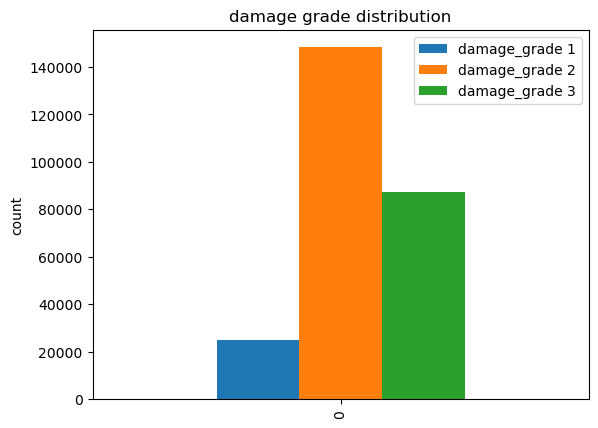

In [9]:
distribution = {
    # 'damage_grade 1': dmg1.size,
    # 'damage_grade 2': dmg2.size,
    # 'damage_grade 3': dmg3.size
    'damage_grade 1': len(dmg1),
    'damage_grade 2': len(dmg2),
    'damage_grade 3': len(dmg3)
}

# Create DataFrame
dist = pd.DataFrame(distribution, index=[0])

print(dist)
dist.plot(kind='bar')
plt.title('damage grade distribution')
# plt.yscale('log')
plt.ylabel('count')
plt.show()

In [10]:
# columnList = df.columns.tolist()
# columnList = df.select_dtypes(include='number').columns.tolist()
columnList = df.drop(['damage_grade', 'building_id', 'geo_level_1_id'], axis = 1).columns.tolist()
# columnList

In [11]:
columnList

['geo_level_2_id',
 'geo_level_3_id',
 'count_floors_pre_eq',
 'age',
 'area_percentage',
 'height_percentage',
 'land_surface_condition',
 'foundation_type',
 'roof_type',
 'ground_floor_type',
 'other_floor_type',
 'position',
 'plan_configuration',
 'has_superstructure_adobe_mud',
 'has_superstructure_mud_mortar_stone',
 'has_superstructure_stone_flag',
 'has_superstructure_cement_mortar_stone',
 'has_superstructure_mud_mortar_brick',
 'has_superstructure_cement_mortar_brick',
 'has_superstructure_timber',
 'has_superstructure_bamboo',
 'has_superstructure_rc_non_engineered',
 'has_superstructure_rc_engineered',
 'has_superstructure_other',
 'legal_ownership_status',
 'count_families',
 'has_secondary_use',
 'has_secondary_use_agriculture',
 'has_secondary_use_hotel',
 'has_secondary_use_rental',
 'has_secondary_use_institution',
 'has_secondary_use_school',
 'has_secondary_use_industry',
 'has_secondary_use_health_post',
 'has_secondary_use_gov_office',
 'has_secondary_use_use_poli

In [12]:
for column in columnList:
    # data = df[['damage_grade', column]]

    # grouped_data = data.groupby(['damage_grade', column])
    # pivot = grouped_data.size().reset_index()
    # print(pivot)


    data = df[['damage_grade', column]]
    # g = data.groupby(['damage_grade', column])
    # categoryTable = g.size().reset_index()
    # categoryTable.columns = ['damage_grade', column, 'count']
    # pivotTable = categoryTable.pivot(index = 'damage_grade', columns = column, values = 'count')
    # pivotTable = pivotTable.fillna(0)
    # # print(pivotTable)
    # #plot if number of columns isn't too high
    # numCol = len(pivotTable.columns)
    # if(numCol < 32):
    #     pivotTable.T.plot(kind='bar')
    #     plt.title(column)
    #     plt.yscale('log')
    #     plt.ylabel('count')
    #     plt.show()
    

## What data is linked to what damage leve? (WIP)
### Low damage level:
(fill in stuff looking at charts)
### Medium damage level:

### High damage level:

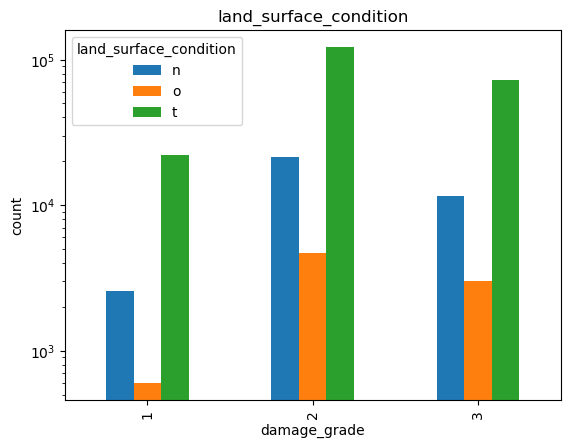

In [13]:
column = 'land_surface_condition'
data = df[['damage_grade', column]]
g = data.groupby(['damage_grade', column])
categoryTable = g.size().reset_index()
categoryTable.columns = ['damage_grade', column, 'count']
pivotTable = categoryTable.pivot(index = 'damage_grade', columns = column, values = 'count')
pivotTable = pivotTable.fillna(0)
# pivotTable
pivotTable.plot(kind='bar')
plt.title(column)
plt.yscale('log')
plt.ylabel('count')
plt.show()

In [35]:
dfNew = df.iloc[:0].copy()
columnList = df.drop(['damage_grade', 'building_id'], axis = 1).columns.tolist()

duplicates = df[df.duplicated(subset=columnList, keep=False)]

In [36]:
duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28544 entries, 1 to 260595
Data columns (total 40 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   building_id                             28544 non-null  int64 
 1   geo_level_1_id                          28544 non-null  int64 
 2   geo_level_2_id                          28544 non-null  int64 
 3   geo_level_3_id                          28544 non-null  int64 
 4   count_floors_pre_eq                     28544 non-null  int64 
 5   age                                     28544 non-null  int64 
 6   area_percentage                         28544 non-null  int64 
 7   height_percentage                       28544 non-null  int64 
 8   land_surface_condition                  28544 non-null  object
 9   foundation_type                         28544 non-null  object
 10  roof_type                               28544 non-null  object
 11  ground

In [37]:
unexpectedValues = 0
iCount = 0
for index, row in duplicates.iterrows():
    for index2, row2 in duplicates.iterrows():
        iCount += 1
        if unexpectedValues % 10000000 == 0:
            print(unexpectedValues, ' ', iCount)
        for col in columnList:
            # if some columns do not match we exit
            if row[col] != row2[col]:
                break
        if row['building_id'] != row2['building_id']:
            if row['damage_grade'] != row2['damage_grade']:
                # print('same features but different damage grade')
                unexpectedValues += 1
print(unexpectedValues)

0   1
0   2
0   3
0   4
0   5


KeyboardInterrupt: 

In [31]:
result = duplicates.sort_values(by=columnList)

In [32]:
result.head(40)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
118081,163439,0,69,3860,2,15,7,5,t,r,...,0,0,0,0,0,0,0,0,0,1
126590,332639,0,69,3860,2,15,7,5,t,r,...,0,0,0,0,0,0,0,0,0,3
60112,432961,0,69,4203,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
234763,862379,0,69,4203,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
143400,469377,0,81,7314,2,25,10,5,t,r,...,0,0,0,0,0,0,0,0,0,2
190503,758006,0,81,7314,2,25,10,5,t,r,...,0,0,0,0,0,0,0,0,0,2
88882,429605,0,114,11078,2,10,7,5,t,r,...,0,0,0,0,0,0,0,0,0,2
225612,990843,0,114,11078,2,10,7,5,t,r,...,0,0,0,0,0,0,0,0,0,2
48989,24140,0,146,10071,2,25,6,4,t,r,...,0,0,0,0,0,0,0,0,0,2
71936,297836,0,146,10071,2,25,6,4,t,r,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
duplicates = duplicates[duplicates.duplicated(subset=columnList, keep=False)]